# PySpark Tutorial: High-Frequency Data Processing and Per-Minute Price Prediction

**Data Description**: `merged_15_common_stocks` contains high-frequency trading data for 15 stocks from January and the first week of February (organized by date subdirectories, one CSV per stock per day).

**Objectives**:
1. Use PySpark for data reading, cleaning, and aggregation (by minute, build price features);
2. Training set = January data, Test set = first week of February data;
3. Build models using PySpark ML library to predict **per-minute price for each stock**.

---

## 0. PySpark Installation and Environment Setup (Recommended to Complete First)

### 0.1 Prerequisites

| Dependency | Requirement | Check Command |
|-----|------|----------|
| Python | 3.8+ | `python --version` |
| Java | JDK 8 / 11 / 17 | `java -version` |
| pip | Latest version | `pip --version` |

### 0.2 Install PySpark

```bash
# Method 1: Install via pip (recommended)
pip install pyspark

# Method 2: Specify version
pip install pyspark==3.5.0

# Method 3: Install to user directory
pip install --user pyspark
```

### 0.3 Install Jupyter and IPykernel (for running this notebook)

```bash
# Install Jupyter
pip install jupyter

# Install/register Python kernel
pip install ipykernel
python -m ipykernel install --user --name python3 --display-name "Python 3 (PySpark)"
```

### 0.4 Verify Installation

```python
# Execute in Python
import pyspark
print("PySpark version:", pyspark.__version__)
# Should output something like: PySpark version: 3.5.0 or 4.x.x
```



---

After completing the above setup, please start from **"1. Create SparkSession and Path Configuration"** below.

In [1]:
# [Optional] Verify PySpark environment: run this cell to check installation
import sys
import subprocess

try:
    import pyspark
    print(f"✓ Python: {sys.version.split()[0]}")
    print(f"✓ PySpark: {pyspark.__version__}")
    try:
        subprocess.run(["java", "-version"], capture_output=True, check=True)
        print("✓ Java: Installed")
    except (subprocess.CalledProcessError, FileNotFoundError):
        print("✗ Java: Not found, please install JDK first")
except ImportError as e:
    print(f"✗ PySpark not installed: {e}\nPlease run: pip install pyspark")

✓ Python: 3.13.4
✓ PySpark: 4.1.1
✓ Java: Installed


## 1. Create SparkSession and Path Configuration

**Spark Architecture Overview**: The Driver is responsible for scheduling, Executors execute tasks; in local mode `local[*]`, both reside in the same JVM.

In [2]:
# Centralized imports (no need to repeat in subsequent cells)
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.functions import input_file_name
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.sql.window import Window
import os
# Java 17+ compatibility: resolves "getSubject is not supported" error
# Must be set before creating SparkSession
_java_opts = (
    "--add-opens java.base/javax.security.auth=ALL-UNNAMED "
    "--add-opens java.base/java.lang=ALL-UNNAMED "
    "--add-opens java.base/java.net=ALL-UNNAMED"
)

# macOS binding fix: force Spark driver to bind on localhost
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

spark = (
    SparkSession.builder
    .appName("HighFreqPricePredict")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.extraJavaOptions", _java_opts)
    .config("spark.executor.extraJavaOptions", _java_opts)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

BASE = os.getcwd()
DATA_ROOT = os.path.join(BASE, "merged_15_common_stocks")
# Partition note: spark.sql.shuffle.partitions=8 controls partition count after shuffle
print("Data root directory:", DATA_ROOT)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/09 13:28:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Data root directory: /Users/yuiqin/Desktop/股票dataset/merged_15_common_stocks


### 1.1 PySpark Core Concepts (Must Read)

**Lazy Evaluation**:
- Transformations (e.g., `filter`, `select`, `withColumn`) do not execute immediately; they only build the DAG
- Actions (e.g., `.show()`, `.count()`, `.collect()`) actually trigger computation
- When reusing the same DataFrame multiple times, use `.cache()` or `.persist()` to avoid redundant computation

**Execution Plan**: `df.explain()` or `df.explain(True)` displays the physical/logical plan, which is fundamental for optimization.

**Caching**: `df.cache()` = `df.persist(StorageLevel.MEMORY_AND_DISK)`; DataFrames used multiple times should be cached.

---

## 2. PySpark Data Cleaning and Exploratory Data Analysis (EDA) In-Depth

The following is based on the `df_raw` data from `merged_15_common_stocks` (loaded in Section 2.1), providing a systematic walkthrough of core PySpark functions for data cleaning, descriptive analysis, transformation, and visualization.

**This chapter covers:**
1. **Descriptive Analysis**: `describe`, `summary`, `count`, `distinct`, cross-tabulation
2. **Missing Value Handling**: `dropna`, `fillna`, `isNull`, `isNotNull`
3. **Type Conversion**: `cast`, `astype`, numeric parsing
4. **String Operations**: `trim`, `regexp_extract`, `substring`, `split`, `concat`
5. **Filtering and Selection**: `filter`, `where`, `select`, `drop`
6. **Aggregation and Grouping**: `groupBy`, `agg`, `pivot`
7. **Data Transformation**: `withColumn`, `when/otherwise`, `coalesce`
8. **Visualization**: Convert to Pandas and plot with matplotlib/seaborn

### 2.1 Read Raw CSV and Parse Date & Stock Code from File Path

The raw CSV files have no headers. Column definitions (0-based): column 6 = stock code, column 8 = trading time (HHMMSS), column 18 = best ask, column 21 = best bid. The `input_file_name()` function retrieves the file path, from which we parse the date (YYYYMMDD) and stock code.

In [103]:
# Read all CSV files from subdirectories (no header), keeping the file path
df_raw = (
    spark.read
    .option("header", False)
    .option("recursiveFileLookup", True)
    .csv(DATA_ROOT)
)

# Add file path column for parsing date and stock code (input_file_name imported at the top)
df_raw = df_raw.withColumn("_path", input_file_name())

# Extract date and stock from path: .../20160104/stock_1319.csv -> date=20160104, stock=1319
df_raw = (
    df_raw
    .withColumn("date", F.regexp_extract(F.col("_path"), "([0-9]{8})/stock_([0-9]+)\\.csv", 1))
    .withColumn("stock_code", F.regexp_extract(F.col("_path"), "([0-9]{8})/stock_([0-9]+)\\.csv", 2))
)

# Select required columns: time (col 7), best ask (col 17), best bid (col 20)
df_raw = (
    df_raw
    .withColumnRenamed("_c7", "time_str")
    .withColumnRenamed("_c17", "best_ask")
    .withColumnRenamed("_c20", "best_bid")
    .select("date", "stock_code", "time_str", "best_ask", "best_bid")
)

# Cache: df_raw is used repeatedly in Section 2 subsections to avoid redundant computation
df_raw.cache()

df_raw.show(5, truncate=False)
print("Total raw records:", df_raw.count())

+--------+----------+--------+--------+--------+
|date    |stock_code|time_str|best_ask|best_bid|
+--------+----------+--------+--------+--------+
|20160129|1802      |NULL    |NULL    |900     |
|20160129|1802      |080000  |901     |900     |
|20160129|1802      |080000  |999     |999     |
|20160129|1802      |080000  |1149    |1149    |
|20160129|1802      |080001  |1149    |1149    |
+--------+----------+--------+--------+--------+
only showing top 5 rows


Total raw records: 2908444


In [104]:
# Lazy evaluation: .explain() shows the execution plan (does not trigger computation)
df_raw.explain()
# Note: .show() and .count() actually trigger computation

== Physical Plan ==
InMemoryTableScan [date#179494, stock_code#179495, time_str#179496, best_ask#179497, best_bid#179498]
   +- InMemoryRelation [date#179494, stock_code#179495, time_str#179496, best_ask#179497, best_bid#179498], StorageLevel(disk, memory, deserialized, 1 replicas)
         +- *(1) Project [regexp_extract(_path#179493, ([0-9]{8})/stock_([0-9]+)\.csv, 1) AS date#179494, regexp_extract(_path#179493, ([0-9]{8})/stock_([0-9]+)\.csv, 2) AS stock_code#179495, _c7#179476 AS time_str#179496, _c17#179486 AS best_ask#179497, _c20#179489 AS best_bid#179498]
            +- *(1) Project [_c7#179476, _c17#179486, _c20#179489, input_file_name() AS _path#179493]
               +- FileScan csv [_c7#179476,_c17#179486,_c20#179489] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/Users/yuiqin/Desktop/股票dataset/merged_15_common_stocks], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<_c7:string,_c17:string,_c20:string>




### 2.2 Descriptive Analysis

| Function | Purpose |
|------|------|
| `df.describe()` | Numeric columns: count, mean, stddev, min, max |
| `df.summary()` | Extended statistics: 25%, 50%, 75% percentiles |
| `df.count()` | Total row count |
| `df.distinct()` | Deduplicate |
| `df.stat.crosstab(col1, col2)` | Cross-tabulation |

In [80]:
# 1. View schema and basic information
print("=== Schema ===")
df_raw.printSchema()
print("\n=== Total Rows ===")
print("Record count:", df_raw.count())

# 2. describe: basic statistics on numeric columns (need to cast to numeric first)
df_num = df_raw.withColumn("ask_double", F.col("best_ask").cast("double")).withColumn("bid_double", F.col("best_bid").cast("double"))
print("\n=== describe (best_ask, best_bid cast to double) ===")
df_num.select("ask_double", "bid_double").describe().show()

# 3. summary: includes percentiles
print("\n=== summary (extended statistics) ===")
df_num.select("ask_double", "bid_double").summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show()

# 4. Distinct: unique (date, stock_code) combinations
print("\n=== Distinct Statistics ===")
print("Unique (date, stock_code) combinations:", df_raw.select("date", "stock_code").distinct().count())
print("Unique date values:", df_raw.select("date").distinct().count())
print("Unique stock_code values:", df_raw.select("stock_code").distinct().count())

# 5. Cross-tabulation: record count per date
print("\n=== Cross-tabulation: record count per date (first 5 rows) ===")
df_raw.groupBy("date").agg(F.count("*").alias("cnt")).orderBy("date").show(5)

=== Schema ===
root
 |-- date: string (nullable = false)
 |-- stock_code: string (nullable = false)
 |-- time_str: string (nullable = true)
 |-- best_ask: string (nullable = true)
 |-- best_bid: string (nullable = true)


=== Total Rows ===
Record count: 2908444

=== describe (best_ask, best_bid cast to double) ===
+-------+------------------+------------------+
|summary|        ask_double|        bid_double|
+-------+------------------+------------------+
|  count|           2908227|           2908066|
|   mean|1026.7071975468216|1024.4244270934703|
| stddev| 1177.678144470331|1172.6161998536325|
|    min|             100.0|             100.0|
|    max|           10800.0|           10640.0|
+-------+------------------+------------------+


=== summary (extended statistics) ===


+-------+------------------+------------------+
|summary|        ask_double|        bid_double|
+-------+------------------+------------------+
|  count|           2908227|           2908066|
|   mean|1026.7071975468216|1024.4244270934703|
| stddev| 1177.678144470331|1172.6161998536325|
|    min|             100.0|             100.0|
|    25%|             704.0|             703.0|
|    50%|             861.0|             860.0|
|    75%|            1002.0|            1001.0|
|    max|           10800.0|           10640.0|
+-------+------------------+------------------+


=== Distinct Statistics ===
Unique (date, stock_code) combinations: 359
Unique date values: 24
Unique stock_code values: 15

=== Cross-tabulation: record count per date (first 5 rows) ===
+--------+------+
|    date|   cnt|
+--------+------+
|20160104| 85756|
|20160105| 91760|
|20160106|102135|
|20160107|103098|
|20160108|132431|
+--------+------+
only showing top 5 rows


### 2.3 Missing Value Handling

| Function | Purpose |
|------|------|
| `df.dropna()` | Drop rows containing null values; can specify columns or threshold |
| `df.fillna(value)` | Fill null values with a specified value |
| `F.col("x").isNull()` | Check if value is null |
| `F.col("x").isNotNull()` | Check if value is not null |

In [105]:
# 1. Count missing values per column
print("=== Missing Value Count per Column ===")
for col_name in df_raw.columns:
    null_count = df_raw.filter(F.col(col_name).isNull()).count()
    print(f"  {col_name}: {null_count}")

# 2. dropna: drop records where best_bid is null
df_no_bid_null = df_raw.dropna(subset=["best_bid"])
print("\n=== Record count after dropna(subset=['best_bid']) ===")
print("Before:", df_raw.count(), "| After:", df_no_bid_null.count())

# 3. fillna: fill best_bid nulls with 0 (example; in practice, could use ask or median)
df_filled = df_raw.fillna(0, subset=["best_bid"])
print("\n=== fillna(0, subset=['best_bid']) example ===")
df_filled.filter(F.col("best_bid") == "0").show(2, truncate=False)

# 4. Conditional filtering: keep only records where best_ask is not null
df_ask_ok = df_raw.filter(F.col("best_ask").isNotNull())
print("\n=== Record count with non-null best_ask ===")
print(df_ask_ok.count())

=== Missing Value Count per Column ===
  date: 0
  stock_code: 0
  time_str: 217
  best_ask: 217
  best_bid: 378

=== Record count after dropna(subset=['best_bid']) ===
Before: 2908444 | After: 2908066

=== fillna(0, subset=['best_bid']) example ===
+----+----------+--------+--------+--------+
|date|stock_code|time_str|best_ask|best_bid|
+----+----------+--------+--------+--------+
+----+----------+--------+--------+--------+


=== Record count with non-null best_ask ===
2908227


### 2.4 Type Conversion

| Function | Purpose |
|------|------|
| `F.col("x").cast("double")` | Cast to double |
| `F.col("x").cast(IntegerType())` | Cast to integer |
| `F.col("x").cast("timestamp")` | Cast to timestamp |
| `F.to_date(col, format)` | Convert string to date |

In [106]:
# 1. cast: string to numeric
from pyspark.sql.types import DoubleType, IntegerType

df_typed = (
    df_raw
    .withColumn("ask_num", F.col("best_ask").cast(DoubleType()))
    .withColumn("bid_num", F.col("best_bid").cast(DoubleType()))
    .withColumn("stock_int", F.col("stock_code").cast(IntegerType()))
)
print("=== Schema after type conversion ===")
df_typed.printSchema()

# 2. Extract hour, minute, second from time_str (HHMMSS) and cast to integer
df_typed = df_typed.withColumn("hour", F.substring(F.col("time_str"), 1, 2).cast("int"))
df_typed = df_typed.withColumn("minute", F.substring(F.col("time_str"), 3, 2).cast("int"))
df_typed = df_typed.withColumn("second", F.substring(F.col("time_str"), 5, 2).cast("int"))
print("\n=== Time parsing example ===")
df_typed.select("time_str", "hour", "minute", "second").show(5)

# 3. Construct mid_price: calculate after casting ask and bid to numeric
df_typed = df_typed.withColumn(
    "mid_price",
    F.when(F.col("bid_num").isNotNull() & (F.col("bid_num") > 0),
          (F.col("ask_num") + F.col("bid_num")) / 2.0)
    .otherwise(F.col("ask_num"))
)
print("\n=== mid_price example ===")
df_typed.select("best_ask", "best_bid", "mid_price").show(5)

=== Schema after type conversion ===
root
 |-- date: string (nullable = false)
 |-- stock_code: string (nullable = false)
 |-- time_str: string (nullable = true)
 |-- best_ask: string (nullable = true)
 |-- best_bid: string (nullable = true)
 |-- ask_num: double (nullable = true)
 |-- bid_num: double (nullable = true)
 |-- stock_int: integer (nullable = true)


=== Time parsing example ===
+--------+----+------+------+
|time_str|hour|minute|second|
+--------+----+------+------+
|    NULL|NULL|  NULL|  NULL|
|  080000|   8|     0|     0|
|  080000|   8|     0|     0|
|  080000|   8|     0|     0|
|  080001|   8|     0|     1|
+--------+----+------+------+
only showing top 5 rows

=== mid_price example ===
+--------+--------+---------+
|best_ask|best_bid|mid_price|
+--------+--------+---------+
|    NULL|     900|     NULL|
|     901|     900|    900.5|
|     999|     999|    999.0|
|    1149|    1149|   1149.0|
|    1149|    1149|   1149.0|
+--------+--------+---------+
only showing top

### 2.5 String Operations

| Function | Purpose |
|------|------|
| `F.trim(col)` | Remove leading and trailing whitespace |
| `F.regexp_extract(col, pattern, idx)` | Regex extraction |
| `F.substring(col, pos, len)` | Extract substring |
| `F.concat(col1, col2)` | Concatenate |
| `F.split(col, sep)` | Split by delimiter |
| `F.col("x").rlike(pattern)` | Regex matching |

In [83]:
# 1. trim: remove leading/trailing whitespace from stock_code
df_str = df_raw.withColumn("stock_code_clean", F.trim(F.col("stock_code")))
print("=== trim example (stock_code with whitespace) ===")
df_raw.select("stock_code").show(2)

# 2. regexp_extract: extract HHMM from time_str
df_str = df_str.withColumn("minute_slot", F.regexp_extract(F.col("time_str"), r"^(\d{4})", 1))
print("\n=== regexp_extract: extract first 4 digits (HHMM) from time_str ===")
df_str.select("time_str", "minute_slot").show(5)

# 3. substring: equivalent approach
df_str = df_str.withColumn("minute_slot2", F.substring(F.col("time_str"), 1, 4))
print("\n=== substring(time_str, 1, 4) ===")
df_str.select("time_str", "minute_slot2").show(5)

# 4. concat: concatenate date + stock_code
df_str = df_str.withColumn("date_stock", F.concat(F.col("date"), F.lit("_"), F.col("stock_code_clean")))
print("\n=== concat example ===")
df_str.select("date", "stock_code_clean", "date_stock").show(3)

# 5. rlike: filter records where date starts with 201601
df_jan = df_raw.filter(F.col("date").rlike("^201601"))
print("\n=== rlike('^201601') filter January data, record count ===")
print(df_jan.count())

=== trim example (stock_code with whitespace) ===
+----------+
|stock_code|
+----------+
|      1802|
|      1802|
+----------+
only showing top 2 rows

=== regexp_extract: extract first 4 digits (HHMM) from time_str ===
+--------+-----------+
|time_str|minute_slot|
+--------+-----------+
|    NULL|       NULL|
|  080000|       0800|
|  080000|       0800|
|  080000|       0800|
|  080001|       0800|
+--------+-----------+
only showing top 5 rows

=== substring(time_str, 1, 4) ===
+--------+------------+
|time_str|minute_slot2|
+--------+------------+
|    NULL|        NULL|
|  080000|        0800|
|  080000|        0800|
|  080000|        0800|
|  080001|        0800|
+--------+------------+
only showing top 5 rows

=== concat example ===
+--------+----------------+-------------+
|    date|stock_code_clean|   date_stock|
+--------+----------------+-------------+
|20160129|            1802|20160129_1802|
|20160129|            1802|20160129_1802|
|20160129|            1802|20160129_180

### 2.6 Filtering and Selection

| Function | Purpose |
|------|------|
| `df.filter(condition)` / `df.where(condition)` | Filter rows by condition |
| `df.select(*cols)` | Select columns |
| `df.drop(*cols)` | Drop columns |
| `df.limit(n)` | Take first n rows |
| `df.orderBy(col)` | Sort |

In [107]:
# 1. filter / where: equivalent
df_filtered = df_raw.filter((F.col("date") == "20160104") & (F.col("stock_code") == "1319"))
print("=== filter: date=20160104 and stock_code=1319 ===")
df_filtered.show(3)

# 2. select: choose specific columns
df_sub = df_raw.select("date", "stock_code", "time_str", "best_ask")
print("\n=== select specific columns ===")
df_sub.show(2)

# 3. drop: remove columns
df_dropped = df_raw.drop("best_bid")
print("\n=== Column names after drop('best_bid') ===")
print(df_dropped.columns)

# 4. orderBy + limit
print("\n=== orderBy + limit(5) ===")
df_raw.orderBy(F.col("date").desc(), F.col("time_str").desc()).limit(5).show()

=== filter: date=20160104 and stock_code=1319 ===
+--------+----------+--------+--------+--------+
|    date|stock_code|time_str|best_ask|best_bid|
+--------+----------+--------+--------+--------+
|20160104|      1319|  080004|     321|    NULL|
|20160104|      1319|  080006|     320|    NULL|
|20160104|      1319|  080038|     310|    NULL|
+--------+----------+--------+--------+--------+
only showing top 3 rows

=== select specific columns ===
+--------+----------+--------+--------+
|    date|stock_code|time_str|best_ask|
+--------+----------+--------+--------+
|20160129|      1802|    NULL|    NULL|
|20160129|      1802|  080000|     901|
+--------+----------+--------+--------+
only showing top 2 rows

=== Column names after drop('best_bid') ===
['date', 'stock_code', 'time_str', 'best_ask']

=== orderBy + limit(5) ===
+--------+----------+--------+--------+--------+
|    date|stock_code|time_str|best_ask|best_bid|
+--------+----------+--------+--------+--------+
|20160205|      178

### 2.7 Aggregation and Grouping

| Function | Purpose |
|------|------|
| `df.groupBy("col").agg(...)` | Group by column and aggregate |
| `F.count("*")` | Count |
| `F.sum`, `F.avg`, `F.min`, `F.max` | Aggregate functions |
| `F.collect_list`, `F.collect_set` | Collect into list/set |
| `df.stat.crosstab(col1, col2)` | Cross-tabulation |

In [85]:
# 1. First construct numeric columns for aggregation
df_agg = df_raw.withColumn("ask_d", F.col("best_ask").cast("double")).withColumn("bid_d", F.col("best_bid").cast("double"))

# 2. groupBy + agg: aggregate by date and stock
print("=== Aggregation by (date, stock_code): record count, avg ask, min ask ===")
df_agg.groupBy("date", "stock_code").agg(
    F.count("*").alias("record_count"),
    F.avg("ask_d").alias("avg_ask"),
    F.min("ask_d").alias("min_ask"),
    F.max("ask_d").alias("max_ask"),
).orderBy("date", "stock_code").show(10)

# 3. Aggregate by date: total records per day
print("\n=== Aggregation by date: daily record count ===")
df_agg.groupBy("date").agg(F.count("*").alias("cnt")).orderBy("date").show(10)

# 4. Conditional aggregation: proportion of non-null best_bid
print("\n=== Non-null best_bid ratio per date ===")
df_agg.withColumn("has_bid", F.when(F.col("bid_d").isNotNull(), 1).otherwise(0)).groupBy("date").agg(
    F.count("*").alias("total"),
    F.sum("has_bid").alias("with_bid"),
).withColumn("bid_ratio", F.col("with_bid") / F.col("total")).select("date", "total", "with_bid", "bid_ratio").show(5)

=== Aggregation by (date, stock_code): record count, avg ask, min ask ===
+--------+----------+------------+------------------+-------+-------+
|    date|stock_code|record_count|           avg_ask|min_ask|max_ask|
+--------+----------+------------+------------------+-------+-------+
|20160104|      1319|         114|273.67543859649123|  268.0|  321.0|
|20160104|      1401|          77|1755.6363636363637| 1671.0| 2009.0|
|20160104|      1405|          62|             694.3|  690.0|  701.0|
|20160104|      1419|         756|435.14021164021165|  357.0|  439.0|
|20160104|      1518|        1253|130.65307753796964|  130.0|  180.0|
|20160104|      1712|        4013|1399.4094193869923| 1316.0| 1450.0|
|20160104|      1722|        4012| 888.9292123629112|  876.0|  946.0|
|20160104|      1743|          39|208.30555555555554|  204.0|  268.0|
|20160104|      1766|        1623| 9209.808995686999| 9120.0| 9900.0|
|20160104|      1780|         372| 444.6064690026954|  366.0|  490.0|
+--------+------

### 2.8 Data Transformation (withColumn, when/otherwise, coalesce)

| Function | Purpose |
|------|------|
| `df.withColumn("new", expr)` | Add or overwrite a column |
| `F.when(cond, val).otherwise(default)` | Conditional branching |
| `F.coalesce(*cols)` | Take the first non-null value |
| `F.lit(value)` | Constant column |

In [86]:
# 1. withColumn + when/otherwise: construct mid_price
df_trans = df_raw.withColumn("ask_d", F.col("best_ask").cast("double")).withColumn("bid_d", F.col("best_bid").cast("double"))

df_trans = df_trans.withColumn(
    "mid_price",
    F.when(F.col("bid_d").isNotNull() & (F.col("bid_d") > 0), (F.col("ask_d") + F.col("bid_d")) / 2.0)
    .otherwise(F.col("ask_d"))
)
print("=== when/otherwise: mid_price = (ask+bid)/2, use ask when bid is missing ===")
df_trans.select("best_ask", "best_bid", "mid_price").show(5)

# 2. coalesce: take first non-null
df_trans = df_trans.withColumn("price_any", F.coalesce(F.col("bid_d"), F.col("ask_d")))
print("\n=== coalesce(bid, ask): prefer bid, fallback to ask ===")
df_trans.select("best_ask", "best_bid", "price_any").show(5)

# 3. Multi-condition when: price level labeling
df_trans = df_trans.withColumn(
    "price_level",
    F.when(F.col("mid_price") < 100, "low")
    .when(F.col("mid_price") < 500, "mid")
    .otherwise("high")
)
print("\n=== Multi-condition when: price level labeling ===")
df_trans.select("mid_price", "price_level").show(10)

# 4. lit: add constant column
df_trans = df_trans.withColumn("source", F.lit("merged_15_stocks"))
print("\n=== lit constant column ===")
df_trans.select("stock_code", "source").show(2)

=== when/otherwise: mid_price = (ask+bid)/2, use ask when bid is missing ===
+--------+--------+---------+
|best_ask|best_bid|mid_price|
+--------+--------+---------+
|    NULL|     900|     NULL|
|     901|     900|    900.5|
|     999|     999|    999.0|
|    1149|    1149|   1149.0|
|    1149|    1149|   1149.0|
+--------+--------+---------+
only showing top 5 rows

=== coalesce(bid, ask): prefer bid, fallback to ask ===
+--------+--------+---------+
|best_ask|best_bid|price_any|
+--------+--------+---------+
|    NULL|     900|    900.0|
|     901|     900|    900.0|
|     999|     999|    999.0|
|    1149|    1149|   1149.0|
|    1149|    1149|   1149.0|
+--------+--------+---------+
only showing top 5 rows

=== Multi-condition when: price level labeling ===
+---------+-----------+
|mid_price|price_level|
+---------+-----------+
|     NULL|       high|
|    900.5|       high|
|    999.0|       high|
|   1149.0|       high|
|   1149.0|       high|
|   1149.0|       high|
|   1129.5

### 2.9 Visualization

PySpark has no built-in plotting. Convert to Pandas first (`.toPandas()` or `.limit(n).toPandas()`) and then use matplotlib/seaborn.

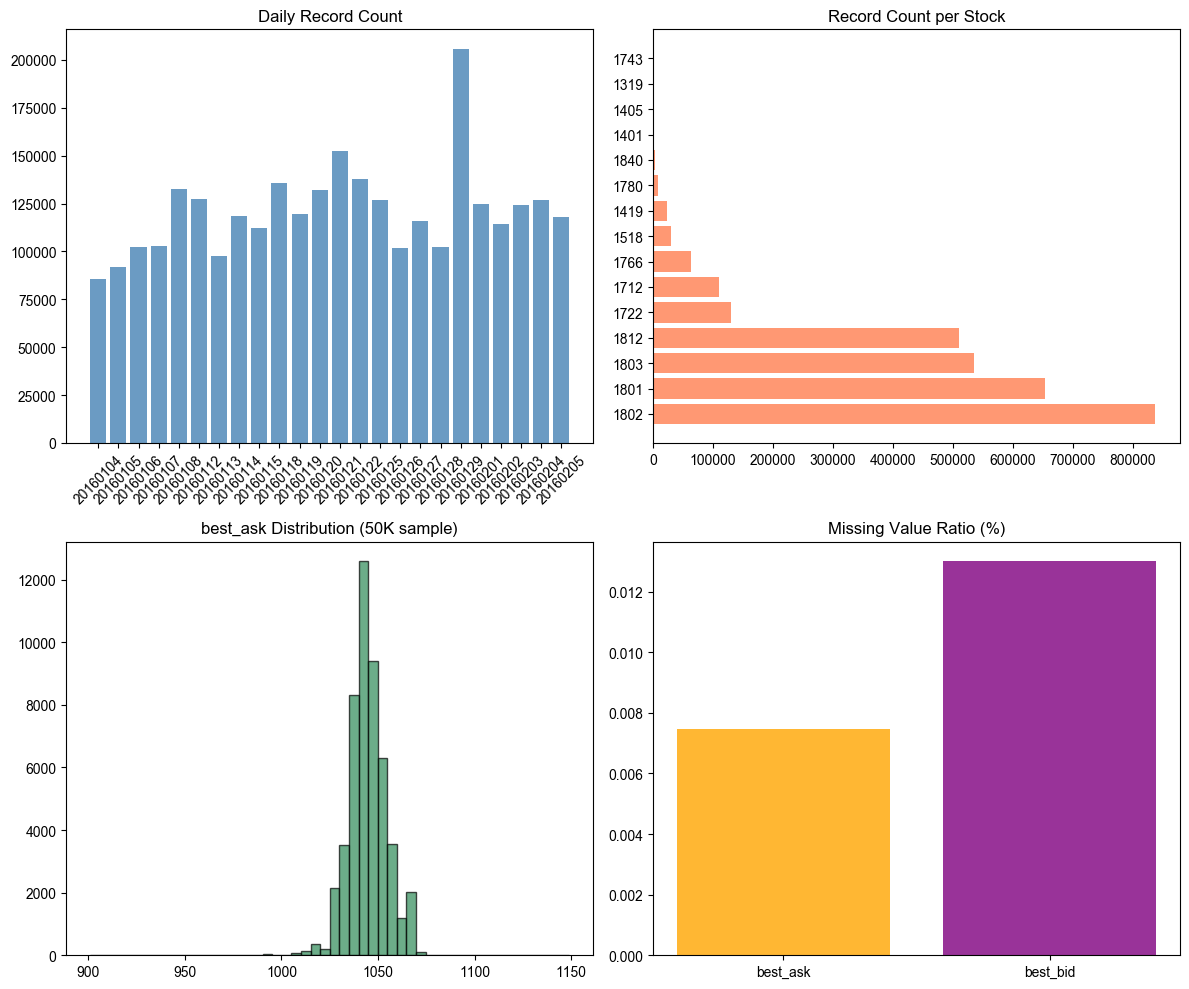

In [108]:
# 1. Convert to Pandas (for large datasets, use limit or sampling)
pdf_daily = df_raw.groupBy("date").agg(F.count("*").alias("cnt")).orderBy("date").toPandas()

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 2. Bar chart: daily record count
axes[0, 0].bar(pdf_daily["date"], pdf_daily["cnt"], color="steelblue", alpha=0.8)
axes[0, 0].set_title("Daily Record Count")
axes[0, 0].tick_params(axis="x", rotation=45)

# 3. Record count per stock
pdf_stock = df_raw.groupBy("stock_code").agg(F.count("*").alias("cnt")).orderBy(F.col("cnt").desc()).toPandas()
axes[0, 1].barh(pdf_stock["stock_code"], pdf_stock["cnt"], color="coral", alpha=0.8)
axes[0, 1].set_title("Record Count per Stock")

# 4. best_ask distribution (sampled to avoid excessive memory usage)
pdf_ask = df_raw.withColumn("ask_d", F.col("best_ask").cast("double")).filter(F.col("ask_d").isNotNull()).limit(50000).select("ask_d").toPandas()
axes[1, 0].hist(pdf_ask["ask_d"], bins=50, color="seagreen", alpha=0.7, edgecolor="black")
axes[1, 0].set_title("best_ask Distribution (50K sample)")

# 5. Missing value ratio
null_ask = df_raw.filter(F.col("best_ask").isNull()).count()
null_bid = df_raw.filter(F.col("best_bid").isNull()).count()
total = df_raw.count()
axes[1, 1].bar(["best_ask", "best_bid"], [null_ask / total * 100, null_bid / total * 100], color=["orange", "purple"], alpha=0.8)
axes[1, 1].set_title("Missing Value Ratio (%)")

plt.tight_layout()
plt.show()

---

The above covers the **PySpark Data Cleaning and Exploratory Data Analysis** in detail based on `merged_15_common_stocks`. After mastering the above functions, you can flexibly apply them to EDA and preprocessing of various DataFrames. Now let's continue with the main workflow: **per-minute aggregation and price calculation**.

## 3. Data Cleaning and Minute-Level Price & Prices

**Problem Description**:
- **Negative R²**: When model predictions are worse than "always predicting the mean," R² < 0. Common causes: weak feature-target relationship, train/test distribution mismatch, non-continuous time series causing distorted lag features.
- **Non-continuous time series**: Raw data only contains minutes with actual trades; minutes without trades have no records. `lag(price, 1)` actually retrieves the "previous row" price, and if there's a multi-minute gap between rows, the price is not a true 1-minute return.
- **This workflow**: Build a complete minute grid → **forward-fill** missing minutes with the most recent available price → then compute price, ensuring the lag represents a true 1-minute interval.

In [109]:
# 1. Clean: cast to numeric, construct price
df_clean = (
    df_raw
    .withColumn("ask", F.col("best_ask").cast(DoubleType()))
    .withColumn("bid", F.col("best_bid").cast(DoubleType()))
    .withColumn("price", F.when(F.col("bid").isNotNull() & (F.col("bid") > 0),
                                   (F.col("ask") + F.col("bid")) / 2.0)
                             .otherwise(F.col("ask")))
    .filter(F.col("price").isNotNull() & (F.col("price") > 0))
)

# 2. Extract minute identifier HHMM from time_str (HHMMSS)
df_clean = df_clean.withColumn("minute", F.substring(F.col("time_str"), 1, 4))

# 3. Aggregate by (date, stock_code, minute): take the last price of each minute (orderBy ensures deterministic F.last)
win_agg = Window.partitionBy("date", "stock_code", "minute").orderBy(F.col("time_str").desc())
df_agg = df_clean.withColumn("_rn", F.row_number().over(win_agg)).filter(F.col("_rn") == 1).drop("_rn").select("date", "stock_code", "minute", "price")

# 4. Build complete minute grid (covering 08:00-15:00; data contains 08:xx trades; excluding lunch break 11:31-12:59)
minute_list = []
for h in range(8, 16):
    if h == 12:
        continue
    for m in range(60):
        if h == 11 and m > 30:
            break
        if h == 15 and m > 0:
            break
        minute_list.append(f"{h:02d}{m:02d}")

df_minutes = spark.createDataFrame([(m,) for m in minute_list], ["minute"])
df_dates_stocks = df_agg.select("date", "stock_code").distinct()
df_grid = df_dates_stocks.crossJoin(df_minutes)

# 5. Left join: minutes with trades retain original price; minutes without trades get null
df_joined = df_grid.join(df_agg, ["date", "stock_code", "minute"], "left")

# 6. Forward fill: fill missing minutes with the previous minute's price (Window imported at the top)
win_fill = Window.partitionBy("date", "stock_code").orderBy("minute")
df_minute = (
    df_joined
    .withColumn("price", F.when(F.col("price").isNotNull(), F.col("price"))
               .otherwise(F.last("price", ignorenulls=True).over(win_fill.rowsBetween(Window.unboundedPreceding, -1))))
)

# 7. Drop first row (no previous value to fill) and rows before the first trade of the day
df_minute = df_minute.filter(F.col("price").isNotNull() & (F.col("price") > 0))

# 8. Construct prev_price (previous minute price) for price prediction
win_return = Window.partitionBy("date", "stock_code").orderBy("minute")
df_minute = (
    df_minute
    .withColumn("prev_price", F.lag("price", 1).over(win_return))
    .filter(F.col("prev_price").isNotNull() & (F.col("prev_price") > 0))
    .select("date", "stock_code", "minute", "price", "prev_price")
)

df_minute.show(10, truncate=False)
print("Minute-level record count (continuous time series + forward fill):", df_minute.count())

## 4. Feature Engineering: Multi-Period Price Lags

Use prices from the past **1 to 6 minutes** as features to predict the current minute's price.

**Current Feature Description:**

| Feature | Meaning |
|--------|------|
| `price_lag1` | Price from 1 minute ago (t-1) |
| `price_lag2` | Price from 2 minutes ago (t-2) |
| `price_lag3` | Price from 3 minutes ago (t-3) |
| `price_lag4` | Price from 4 minutes ago (t-4) |
| `price_lag5` | Price from 5 minutes ago (t-5) |
| `price_lag6` | Price from 6 minutes ago (t-6) |

**Target Variable**: `price` = current minute's price (t)

In [112]:
win_feat = Window.partitionBy("date", "stock_code").orderBy("minute")
df_feat = (
    df_minute
    .withColumn("price_lag1", F.lag("price", 1).over(win_feat))
    .withColumn("price_lag2", F.lag("price", 2).over(win_feat))
    .withColumn("price_lag3", F.lag("price", 3).over(win_feat))
    .withColumn("price_lag4", F.lag("price", 4).over(win_feat))
    .withColumn("price_lag5", F.lag("price", 5).over(win_feat))
    .withColumn("price_lag6", F.lag("price", 6).over(win_feat))
    .filter(
        F.col("price_lag1").isNotNull()
        & F.col("price_lag2").isNotNull()
        & F.col("price_lag3").isNotNull()
        & F.col("price_lag4").isNotNull()
        & F.col("price_lag5").isNotNull()
        & F.col("price_lag6").isNotNull()
    )
)

feature_cols = ["price_lag1", "price_lag2", "price_lag3", "price_lag4", "price_lag5", "price_lag6"]
print("Feature columns:", feature_cols)
df_feat.show(5, truncate=False)

## 5. Train / Test Split

- **Training set**: January data (date starting with 201601);
- **Test set**: First week of February (20160201 to 20160205).

In [113]:
train_df = df_feat.filter(F.col("date").rlike("^201601"))
test_df = df_feat.filter(
    (F.col("date") >= "20160201") & (F.col("date") <= "20160205")
)

print("Training set size:", train_df.count())
print("Test set size:", test_df.count())
train_df.show(3, truncate=False)

Training set size: 92278


Test set size: 24370


+--------+----------+------+-----+----------+------------+----------------------+----------------------+----------------------+---------------------+---------------------+
|date    |stock_code|minute|price|price_lag|price_lag_1|price_lag_2          |price_lag_3          |price_lag_4          |price_lag_5         |price_lag_6         |
+--------+----------+------+-----+----------+------------+----------------------+----------------------+----------------------+---------------------+---------------------+
|20160104|1319      |0807  |270.5|0.0       |0.0         |-0.0018450184501845018|0.0                   |0.0                   |-0.014545454545454545|-0.11290322580645161 |
|20160104|1319      |0808  |270.5|0.0       |0.0         |0.0                   |-0.0018450184501845018|0.0                   |0.0                  |-0.014545454545454545|
|20160104|1319      |0809  |270.5|0.0       |0.0         |0.0                   |0.0                   |-0.0018450184501845018|0.0                 

## 5a. Core Prediction Logic: Why R² Remains Small, How Prediction Works, and Cross-Stock Relationships

### I. What Is the Core of the Prediction

**Core Assumption**: Use **prices from the past 1 to 6 minutes** to predict the **current minute's price**. This is essentially an autoregressive (AR) model:

$$\hat{y}_t = f(r_{t-1}, r_{t-2}, \ldots, r_{t-6})$$

where $r_t = (P_t - P_{t-1})/P_{t-1}$ is the price at minute $t$. The model assumes short-term momentum or mean reversion exists, which can be captured using historical returns to predict the next one.

### II. How Prediction Is Performed in Practice

1. **Input**: For each sample `(date, stock_code, minute)`, extract `price_1` through `price_6` to form the feature vector `[r_{t-1}, ..., r_{t-6}]`.
2. **Model**: `model.predict(features)` outputs a scalar — the predicted `price`.
3. **Training**: Minimize the error (MSE, etc.) between predicted and actual `price` on the training set.
4. **Prediction**: Each test sample is predicted **independently** — no sequential/recursive forecasting.

### III. What Is the Relationship Between Different Stocks During Prediction

**Current Design: There is no direct connection between stocks.**

- Each sample `(date, stock_code, minute)` is treated as an independent observation.
- The model does **not** use `stock_code` as a feature; all stocks share the same set of parameters.
- The model learns a **global** relationship: given `[r_{t-1}, ..., r_{t-6}]`, predict `r_t`, regardless of which stock.
- Predictions for Stock A and Stock B are independent; the model does not explicitly leverage cross-stock information.

### IV. Why R² Is Still Very Small (Even After Time Series Completion)

| Reason | Explanation |
|------|------|
| **1. Prices have inherently weak predictive power** | In efficient markets, historical returns have very limited explanatory power for the next minute's return. |
| **2. High noise** | Single-minute return fluctuations are large, the signal-to-noise ratio is low, and the predictable component is limited. |
| **3. Limited features** | Only 6 prices are used; volatility, volume, cross-stock information, etc. are missing. |
| **4. Single global model** | All stocks share one model, unable to capture stock-specific behavioral patterns. |
| **5. Train/test time gap** | Training on January, testing on February — regime changes may exist. |

**Conclusion**: Even with continuous time series and imputed missing values, R² may still be close to 0 or negative, because **minute-level prices are inherently very difficult to predict**.

### V. Possible Improvements (For Extension)

- Add `stock_code` encoding (e.g., OneHot) for stock-specific modeling.
- Include volatility, volume, cross-stock lag features.
- Train separate models per stock or industry.
- Reframe as classification (up/down/flat) instead of regression.

## 6. PySpark ML: LinearRegression + 5-Fold Cross-Validation + ROC Curve

Use **LinearRegression** for regression prediction with **5-fold cross-validation** for hyperparameter tuning; also convert the problem to binary classification (up/down) and plot the **ROC curve**.

### 6.1 ROC Curve (Binary Classification: Up/Down)

Treat `price > 0` as the positive class (up), use LogisticRegression to predict direction, and plot the ROC curve.

In [114]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# feature_cols defined in Section 4
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
lr = LinearRegression(featuresCol="features", labelCol="price", maxIter=50)

# 5-fold cross-validation
param_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5])
    .build()
)

evaluator = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")
cv = CrossValidator(
    estimator=Pipeline(stages=[assembler, lr]),
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=5,
    seed=42,
)

cv_model = cv.fit(train_df)
model = cv_model.bestModel
predictions = model.transform(test_df)

print("5-fold CV average RMSE per parameter combination:", cv_model.avgMetrics)
print("5-fold CV best average RMSE:", min(cv_model.avgMetrics))
print("Test set RMSE:", evaluator.evaluate(predictions))
predictions.select("date", "stock_code", "minute", "price", "prediction").show(10, truncate=False)

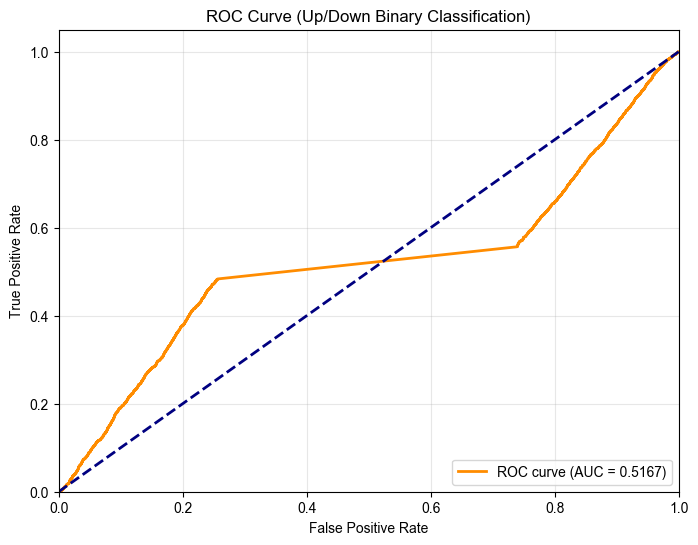

In [115]:
# Binary classification: price > 0 is up (1), otherwise down (0)
from pyspark.ml.classification import LogisticRegression

train_clf = train_df.withColumn("label_bin", F.when(F.col("price") > 0, 1.0).otherwise(0.0))
test_clf = test_df.withColumn("label_bin", F.when(F.col("price") > 0, 1.0).otherwise(0.0))

assembler_clf = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
log_reg = LogisticRegression(featuresCol="features", labelCol="label_bin", maxIter=50)
pipeline_clf = Pipeline(stages=[assembler_clf, log_reg])
model_clf = pipeline_clf.fit(train_clf)
pred_clf = model_clf.transform(test_clf)

# Extract positive class probability (second element) from the probability column
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType
extract_prob = udf(lambda v: float(v[1]) if v is not None else 0.0, DoubleType())
pdf_roc = pred_clf.withColumn("prob", extract_prob("probability")).select("label_bin", "prob").toPandas()

# Plot ROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(pdf_roc["label_bin"], pdf_roc["prob"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Up/Down Binary Classification)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Model Evaluation

Compute RMSE, MAE, and R² on the test set, along with **regression evaluation visualizations** (scatter plot, residual plot) and **classification confusion matrix** (evaluating after converting price to up/down/flat three-class labels).

**Meaning of Negative R²**: R² = 1 - (SS_res / SS_tot). When the model's residual sum of squares is **greater** than the mean-prediction sum of squares, R² < 0. This means the model's predictions are worse than simply predicting the mean. Common causes: weak feature-target relationship, train/test distribution mismatch, non-continuous time series causing distorted lag features.

In [116]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_rmse = RegressionEvaluator(
    labelCol="price", predictionCol="prediction", metricName="rmse"
)
evaluator_mae = RegressionEvaluator(
    labelCol="price", predictionCol="prediction", metricName="mae"
)
evaluator_r2 = RegressionEvaluator(
    labelCol="price", predictionCol="prediction", metricName="r2"
)

rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print("Test Set Price Prediction Performance:")
print("  RMSE:", rmse)
print("  MAE:", mae)
print("  R²:", r2)

### 7a. Regression Evaluation Visualization

Evaluation visualizations for the **regression model** (predicting continuous price): predicted vs. actual scatter plot, residual distribution, and error distribution.

In [117]:
# Regression evaluation visualization: convert to Pandas and plot
pdf_eval = predictions.select("price", "prediction").limit(10000).toPandas()
pdf_eval["residual"] = pdf_eval["price"] - pdf_eval["prediction"]

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Predicted vs. Actual scatter plot
axes[0, 0].scatter(pdf_eval["price"], pdf_eval["prediction"], alpha=0.3, s=5)
axes[0, 0].plot([pdf_eval["price"].min(), pdf_eval["price"].max()],
                [pdf_eval["price"].min(), pdf_eval["price"].max()], "r--", lw=2, label="Ideal line y=x")
axes[0, 0].set_xlabel("Actual price")
axes[0, 0].set_ylabel("Predicted")
axes[0, 0].set_title("Predicted vs. Actual")
axes[0, 0].legend()

# 2. Residual distribution histogram
axes[0, 1].hist(pdf_eval["residual"], bins=80, color="steelblue", alpha=0.7, edgecolor="black")
axes[0, 1].axvline(0, color="red", linestyle="--")
axes[0, 1].set_xlabel("Residual (Actual - Predicted)")
axes[0, 1].set_title("Residual Distribution")

# 3. Metrics bar chart
metrics = ["RMSE", "MAE", "R²"]
values = [rmse, mae, r2]
colors = ["#e74c3c", "#f39c12", "#27ae60"]
axes[1, 0].bar(metrics, values, color=colors, alpha=0.8)
axes[1, 0].set_title("Regression Metrics")
axes[1, 0].tick_params(axis="x", rotation=0)

# 4. Residual vs. Predicted (check heteroscedasticity)
axes[1, 1].scatter(pdf_eval["prediction"], pdf_eval["residual"], alpha=0.3, s=5)
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Residual")
axes[1, 1].set_title("Residual vs. Predicted")

plt.tight_layout()
plt.show()

### 7b. Classification Task: Confusion Matrix and Multi-Class Evaluation

Convert **prices** to discrete categories (up/down/neutral), train a classifier, then visualize with confusion matrix, precision, recall, F1, ROC, etc.

In [119]:
# 1. Convert price to three-class label: down(-1) / neutral(0) / up(1)
# Threshold adjustable: |price| < 0.0005 is treated as neutral
THRESH = 0.0005

train_clf = train_df.withColumn(
    "label_cls",
    F.when(F.col("price") < -THRESH, 0)   # down
    .when(F.col("price") > THRESH, 2)     # up
    .otherwise(1)                               # neutral
)
test_clf = test_df.withColumn(
    "label_cls",
    F.when(F.col("price") < -THRESH, 0)
    .when(F.col("price") > THRESH, 2)
    .otherwise(1)
)

# 2. Train classifier
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

assembler_clf = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
rf_clf = RandomForestClassifier(featuresCol="features", labelCol="label_cls", numTrees=50, maxDepth=5, seed=42)
pipeline_clf = Pipeline(stages=[assembler_clf, rf_clf])
model_clf = pipeline_clf.fit(train_clf)
pred_clf = model_clf.transform(test_clf)

# 3. Confusion matrix: count (label_cls, prediction) combinations
from pyspark.sql.types import IntegerType
pred_clf = pred_clf.withColumn("pred_cls", F.col("prediction").cast(IntegerType()))

# Collect confusion matrix
cm_rows = pred_clf.groupBy("label_cls", "pred_cls").agg(F.count("*").alias("cnt")).orderBy("label_cls", "pred_cls").collect()

# Build 3x3 confusion matrix
import numpy as np
cm = np.zeros((3, 3))
for r in cm_rows:
    cm[int(r["label_cls"]), int(r["pred_cls"])] = r["cnt"]

labels = ["down", "neutral", "up"]
print("Confusion Matrix (rows=actual, columns=predicted):")
print("        ", "  ".join(f"{l:>8}" for l in labels))
for i, row in enumerate(cm):
    print(f"{labels[i]:>8}", "  ".join(f"{v:>8.0f}" for v in row))

Confusion Matrix (rows=actual, columns=predicted):
             down   neutral        up
    down        9      3123         1
 neutral        8     18149         1
      up        6      3072         1


Classification Evaluation Metrics:
  Accuracy:   0.7451
  F1 (macro): 0.6372
  Precision (weighted): 0.6479
  Recall (weighted):    0.7451


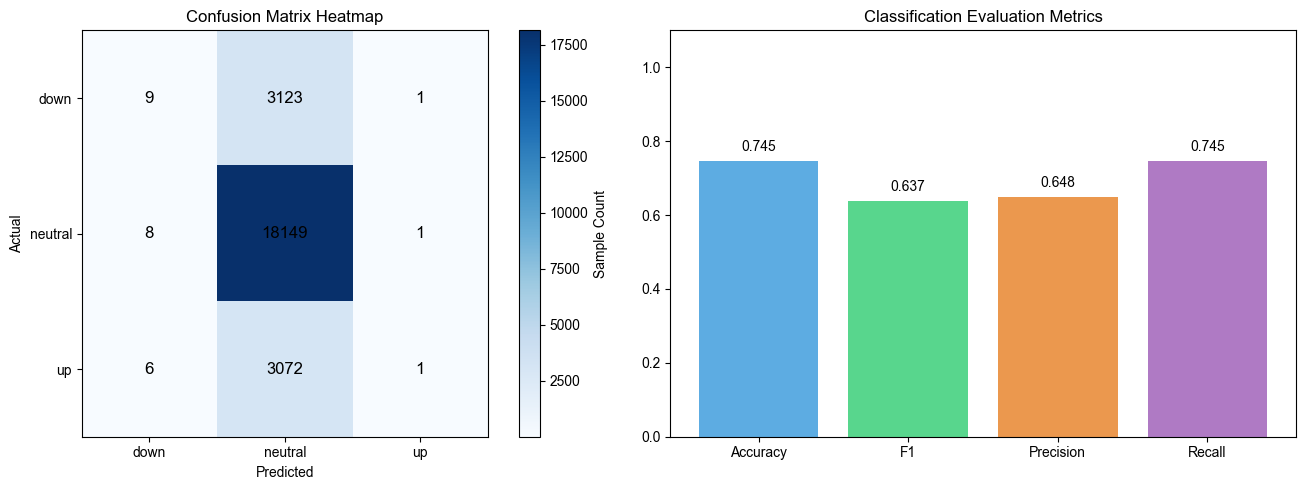

In [120]:
# 4. Confusion matrix heatmap + multi-class metrics
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label_cls", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label_cls", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label_cls", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label_cls", predictionCol="prediction", metricName="weightedRecall")

acc = evaluator_acc.evaluate(pred_clf)
f1 = evaluator_f1.evaluate(pred_clf)
precision = evaluator_precision.evaluate(pred_clf)
recall = evaluator_recall.evaluate(pred_clf)

print("Classification Evaluation Metrics:")
print("  Accuracy:  ", round(acc, 4))
print("  F1 (macro):", round(f1, 4))
print("  Precision (weighted):", round(precision, 4))
print("  Recall (weighted):   ", round(recall, 4))

# Confusion matrix heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
import numpy as np
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1, 2])
axes[0].set_yticks([0, 1, 2])
axes[0].set_xticklabels(labels)
axes[0].set_yticklabels(labels)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix Heatmap")
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{int(cm[i,j])}", ha="center", va="center", fontsize=12)
plt.colorbar(im, ax=axes[0], label="Sample Count")

# Metrics bar chart
metrics_clf = ["Accuracy", "F1", "Precision", "Recall"]
values_clf = [acc, f1, precision, recall]
axes[1].bar(metrics_clf, values_clf, color=["#3498db", "#2ecc71", "#e67e22", "#9b59b6"], alpha=0.8)
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Classification Evaluation Metrics")
for i, v in enumerate(values_clf):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

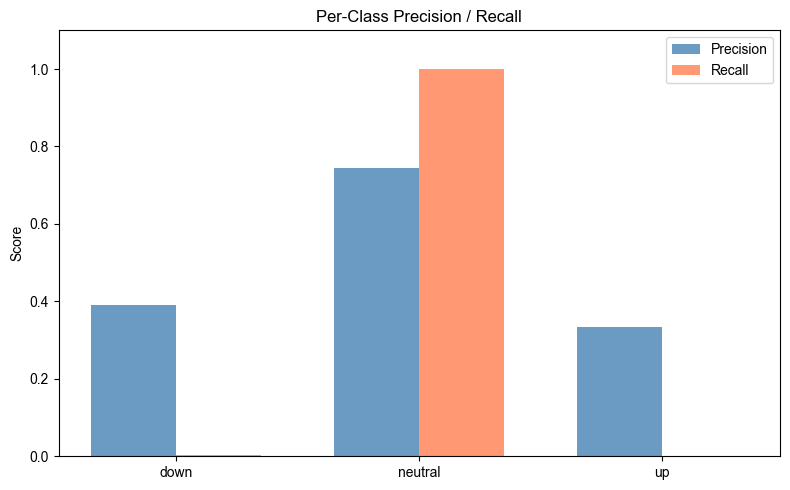

In [121]:
# 5. Per-class Precision / Recall bar chart (manually computed)
# TP_i = cm[i,i]; for class i: Precision = TP_i / (total predicted as i), Recall = TP_i / (total actually i)
precision_per_class = []
recall_per_class = []
for i in range(3):
    tp = cm[i, i]
    pred_i = cm[:, i].sum()
    true_i = cm[i, :].sum()
    prec = tp / pred_i if pred_i > 0 else 0
    rec = tp / true_i if true_i > 0 else 0
    precision_per_class.append(prec)
    recall_per_class.append(rec)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(labels))
bar_width = 0.35
ax.bar(x - bar_width/2, precision_per_class, bar_width, label="Precision", color="steelblue", alpha=0.8)
ax.bar(x + bar_width/2, recall_per_class, bar_width, label="Recall", color="coral", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall")
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## 8. Summary

- **Data Processing**: PySpark reads multi-directory CSVs, parses date/stock from file paths, aggregates by minute, and uses window functions to compute prices and multi-period lag features.
- **Machine Learning**: 6-period price features, **LinearRegression** + 5-fold cross-validation; binary classification (up/down) with ROC curve.
- Features: `price_1` through `price_6`; Target: current minute's price.

In [122]:
spark.stop()